# Preprocessing Experiment for Multilabel Classification

## 1. Load Data

In [1]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.visualization import make_lupton_rgb
from scipy.ndimage import gaussian_filter

import torch
from torchvision import transforms

#local imports
from visualizations import Visualization, Transformations
from galaxy_transforms import SkySubstractTransform, LuptonRgbTransform, UnsharpMaskTransform, MultiScaleUnsharpMaskTransform, EnsureCHWTransform, ToTensorIfNumpy

# Multilabel class mapping
RING_CLASS_TO_MULTILABEL = {
    0: [0, 0],  # No rings
    1: [1, 0],  # Inner ring only
    2: [0, 1],  # Outer ring only
    3: [1, 1]   # Both rings
}


In [2]:
#Optimize PyTorch performance
RANDOM_SEED = 42

torch.set_float32_matmul_precision('high')
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

In [3]:
# Set up paths
current_dir = os.getcwd()
path = os.path.join(current_dir)
data_path = os.path.join(path, 'Data')
model_path = os.path.join(path, 'Models')
os.makedirs(data_path, exist_ok=True)
os.makedirs(model_path, exist_ok=True)

#set image_path to D:\ML Data\FitsGalaxies using os.path.join
image_path = os.path.join("D:\\", "ML Data", "FitsGalaxies")

HOME_PATH = path
DATA_PATH = data_path
MODEL_PATH = model_path
IMAGE_PATH = image_path

print(f"HOME_PATH: {HOME_PATH}")
print(f"DATA_PATH: {DATA_PATH}")
print(f"MODEL_PATH: {MODEL_PATH}")
print(f"IMAGE_PATH: {IMAGE_PATH}")

DATASET_CSV = 'dataset_all_with_files_patched.csv'

HOME_PATH: d:\ML Projects\RingMultilabelClassification
DATA_PATH: d:\ML Projects\RingMultilabelClassification\Data
MODEL_PATH: d:\ML Projects\RingMultilabelClassification\Models
IMAGE_PATH: D:\ML Data\FitsGalaxies


In [4]:
# Load dataset
df_dataset = pd.read_csv(os.path.join(DATA_PATH, DATASET_CSV))

print("Dataset Information:")
print(f"\nDataset shape: {df_dataset.shape}")
print(f"\nColumn names: {df_dataset.columns.tolist()}")
print(f"\nBasic Statistics:\n {df_dataset.describe()}")
print(f"\nFirst few rows:")
print(df_dataset.head())

# Check ring_class distribution
print(f"\n\nRing Class Distribution:")
ring_dist = df_dataset['ring_class'].value_counts().sort_index()
print(ring_dist)

print(f"\n\nMultilabel Distribution (inner_ring, outer_ring):")
if 'inner_ring' in df_dataset.columns and 'outer_ring' in df_dataset.columns:
    multilabel_dist = df_dataset.groupby(['inner_ring', 'outer_ring']).size()
    print(multilabel_dist)

Dataset Information:

Dataset shape: (8346, 15)

Column names: ['id_str', 'ra', 'dec', 'z', 'anillos', 'dataset', 'ring_class', 'ring_class_0', 'ring_class_1', 'ring_class_2', 'ring_class_3', 'inner_ring', 'outer_ring', 'file_loc', 'validation_status']

Basic Statistics:
                 ra          dec            z      anillos   ring_class  \
count  8346.000000  8346.000000  8346.000000  8346.000000  8346.000000   
mean    184.653690    25.366616     0.034619     1.529835     0.382459   
std      60.193130    18.306968     0.013316     3.144514     0.786128   
min       0.008759   -11.015802     0.007122     0.000000     0.000000   
25%     153.537672    10.777381     0.024547     0.000000     0.000000   
50%     187.332100    24.622751     0.032400     0.000000     0.000000   
75%     221.278928    39.432592     0.043344     0.000000     0.000000   
max     359.276680    70.133229     0.090440    12.000000     3.000000   

       ring_class_0  ring_class_1  ring_class_2  ring_class_

In [5]:
df_dataset.head()

,id_str,ra,dec,z,anillos,dataset,ring_class,ring_class_0,ring_class_1,ring_class_2,ring_class_3,inner_ring,outer_ring,file_loc,validation_status
0,manga-10001-1902,134.193923,56.786747,0.025391,4,manga,1,0.0,1.0,0.0,0.0,1,0,D:\ML Data\Downloader\Images\manga-10001-1902_...,ok
1,manga-10001-6103,134.008123,57.390964,0.040626,8,manga,2,0.0,0.0,1.0,0.0,0,1,D:\ML Data\Downloader\Images\manga-10001-6103_...,ok
2,manga-10213-12705,122.931168,41.554978,0.031548,4,manga,1,0.0,1.0,0.0,0.0,1,0,D:\ML Data\Downloader\Images\manga-10213-12705...,ok
3,manga-10213-1901,124.082784,43.447637,0.024198,4,manga,1,0.0,1.0,0.0,0.0,1,0,D:\ML Data\Downloader\Images\manga-10213-1901_...,ok
4,manga-10213-6103,121.096387,43.582589,0.040901,4,manga,1,0.0,1.0,0.0,0.0,1,0,D:\ML Data\Downloader\Images\manga-10213-6103_...,ok


## 2. Preprocessing

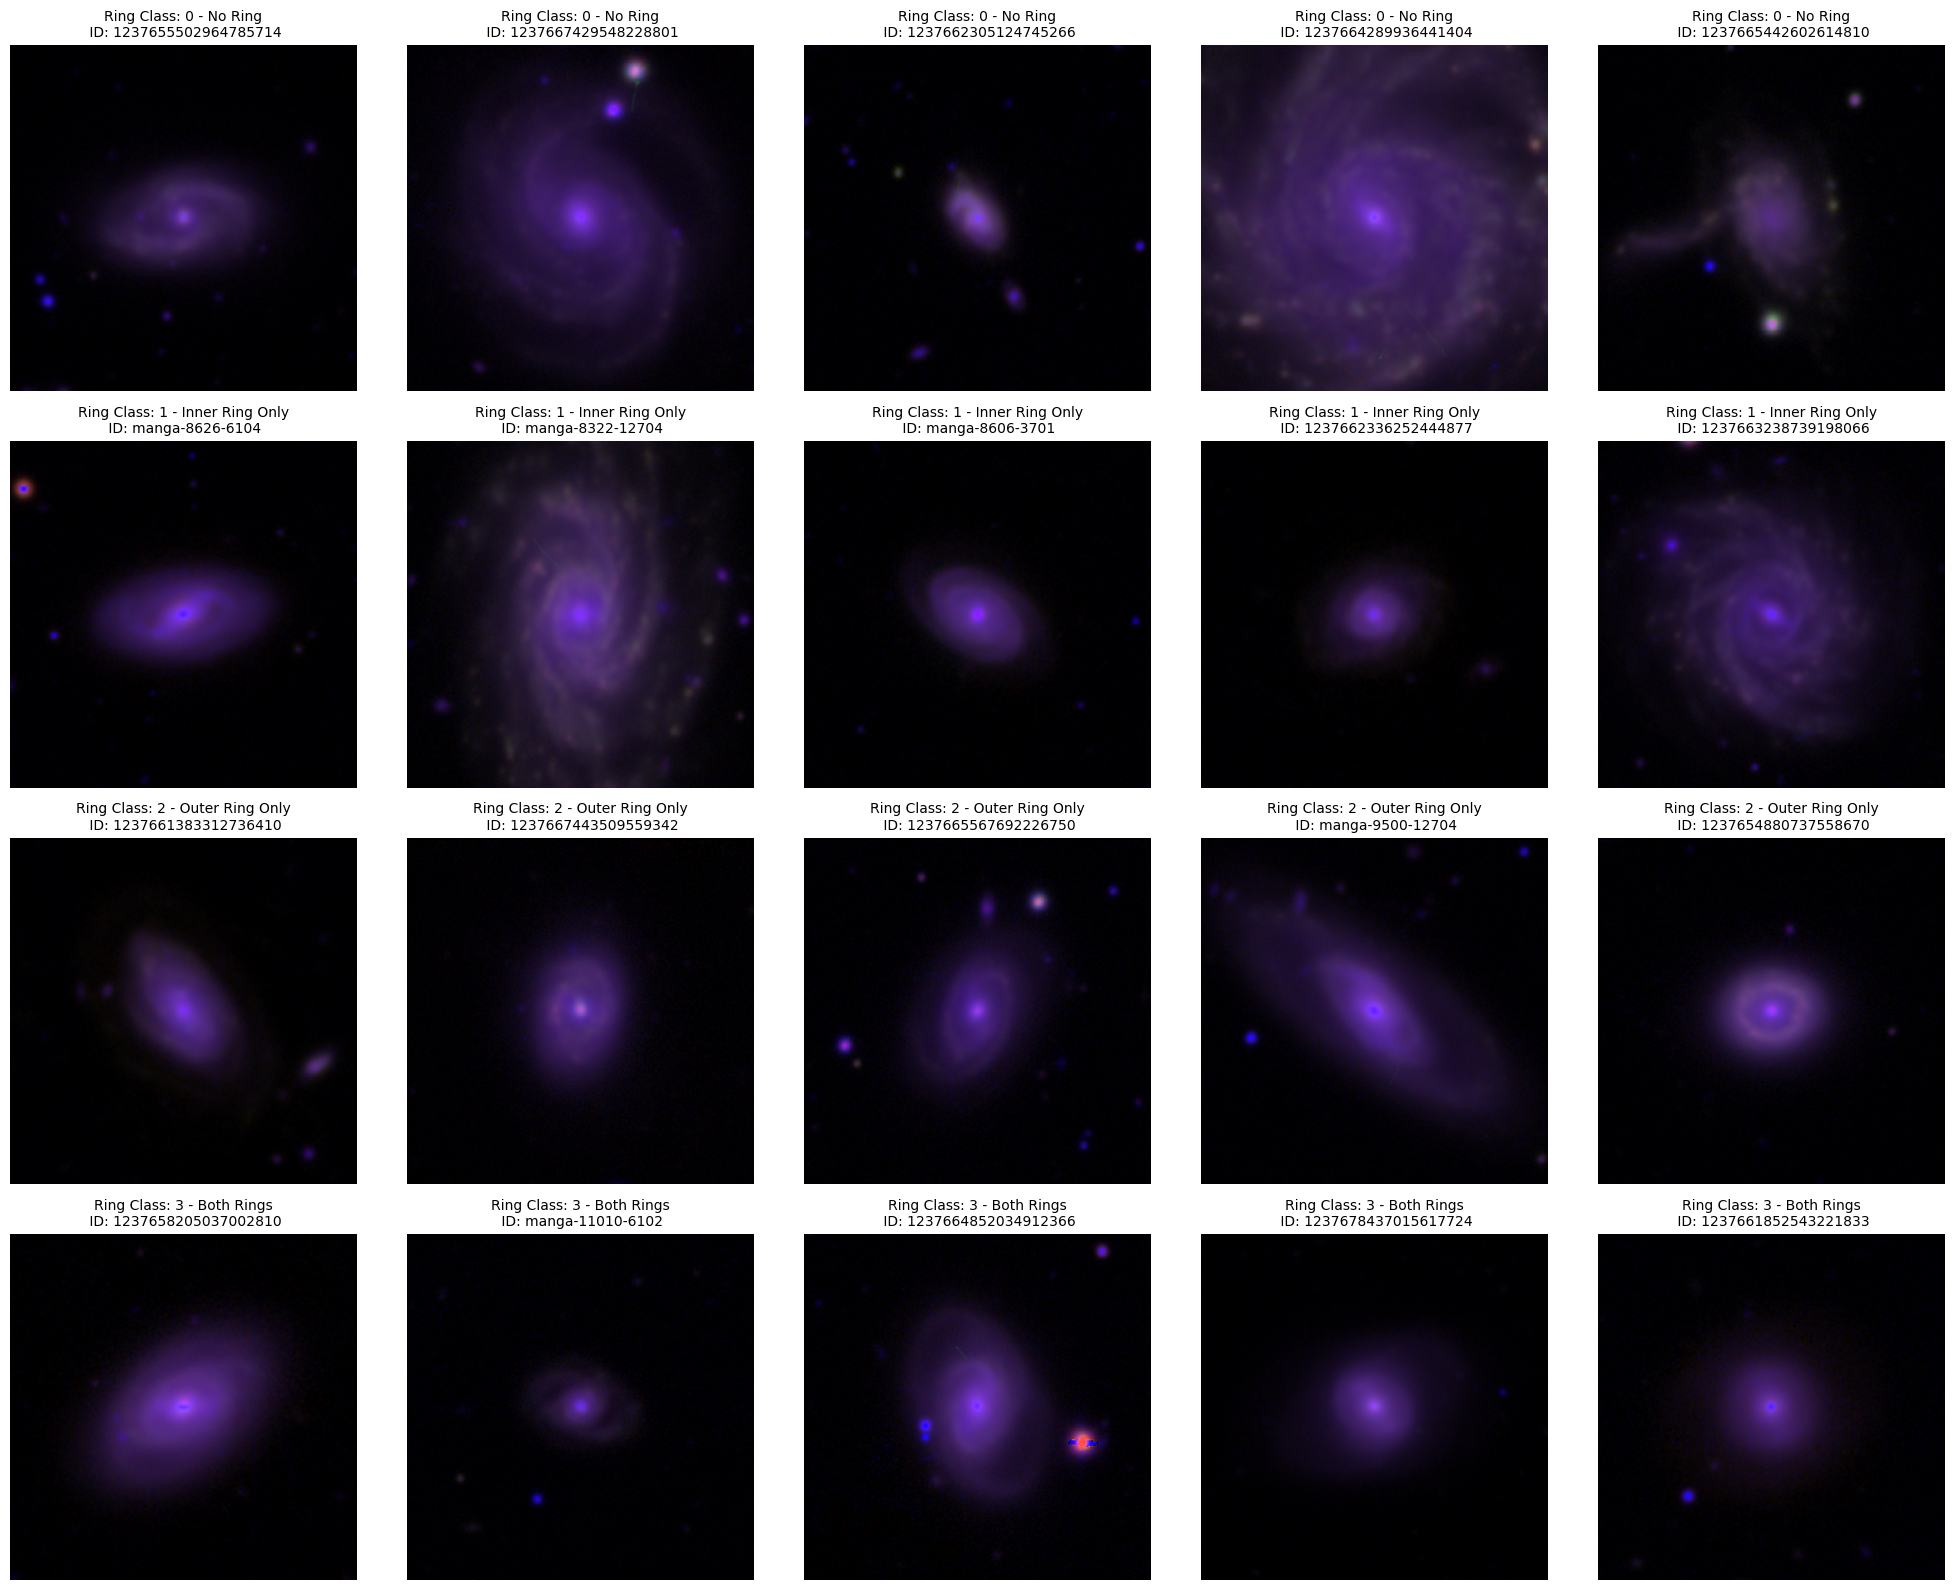

In [6]:

sampled_df = df_dataset.groupby('ring_class').sample(n=5, random_state=42)

Visualization.plot_rgb_image(sampled_df)


In [ ]:
sample1_pipeline = transforms.Compose([
    MultiScaleUnsharpMaskTransform(
        sigmas=(2.5, 6.0),
        amounts=(0.6, 1.3),
        thresholds=(0.010, 0.004),
        clip_percentiles=(0.1, 99.9),
        z_amount_boost=0.0,  # keep 0 at first; your current +2.0 is quite strong
    ),
    SkySubstractTransform(),
    LuptonRgbTransform(),
    EnsureCHWTransform(),
    transforms.ConvertImageDtype(torch.float32),
    transforms.Resize((224, 224)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToPILImage(),
])
sample2_pipeline = transforms.Compose([
    MultiScaleUnsharpMaskTransform(
        sigmas=(2.0, 5.5),
        amounts=(0.45, 1.0),
        thresholds=(0.015, 0.003),
        clip_percentiles=(0.2, 99.8),
        z_amount_boost=0.0,  # keep 0 at first; your current +2.0 is quite strong
    ),
    SkySubstractTransform(),
    LuptonRgbTransform(),
    EnsureCHWTransform(),
    transforms.ConvertImageDtype(torch.float32),
    transforms.Resize((224, 224)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToPILImage(),
])

Visualization.plot_rgb_image(sampled_df, sample2_pipeline)

NameError: name 'AsinhRescaleTransform' is not defined

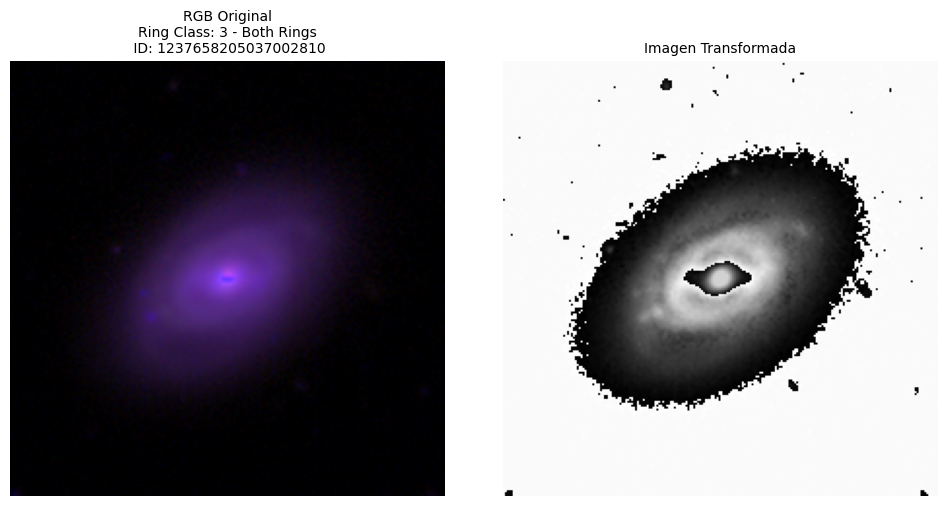

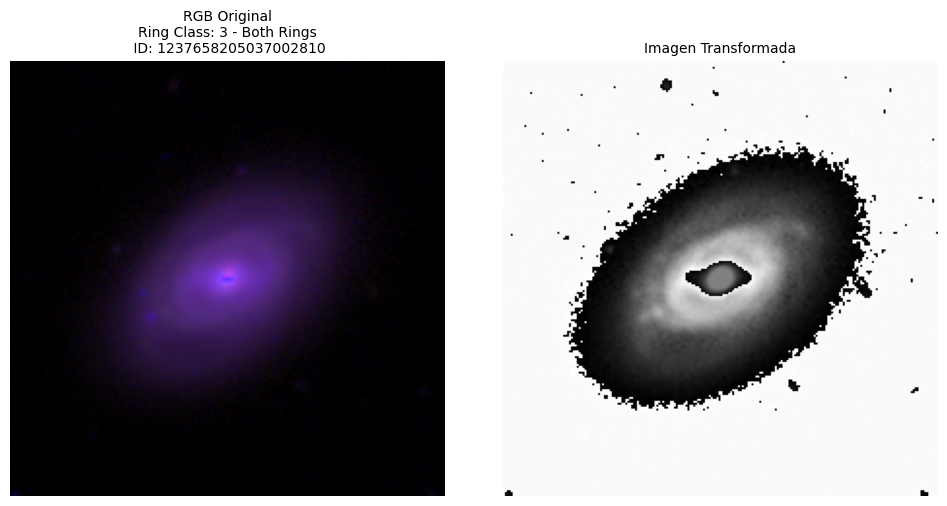

In [ ]:
#extract example manga-8626-6104 from the dataset and visualize it
#[0, 0]
#example_id = '1237664289936441404'

#[1, 0]
#example_id = 'manga-8322-12704'

#[0, 1]
#example_id = '1237665567692226750'

#[1, 1]
example_id = '1237658205037002810'

example_row = Visualization.extract_example(df_dataset, example_id, plot_rgb=True, transform=sample1_pipeline)
example_row2 = Visualization.extract_example(df_dataset, example_id, plot_rgb=True, transform=sample2_pipeline)

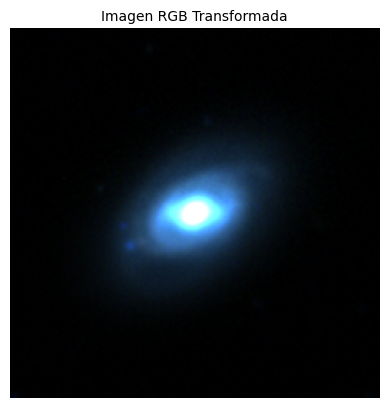

R channel range: -0.009679484 to 4.575599
G channel range: -0.020975614 to 11.177524
Z channel range: -0.03589069 to 21.227444


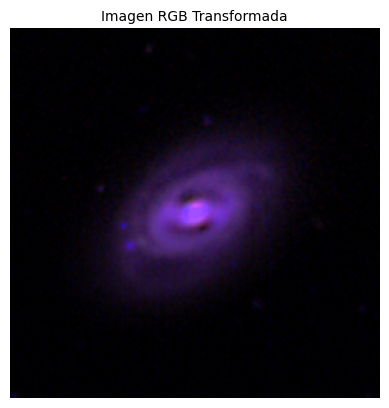

R channel range: 0.0 to 0.81464314
G channel range: 0.0 to 0.36296293
Z channel range: 0.0 to 1.0000002


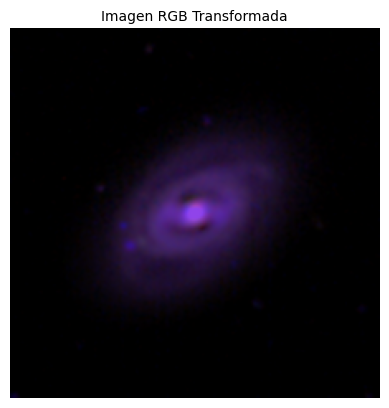

R channel range: 0.0 to 0.61253947
G channel range: 0.0 to 0.2757482
Z channel range: 0.0 to 0.9324621


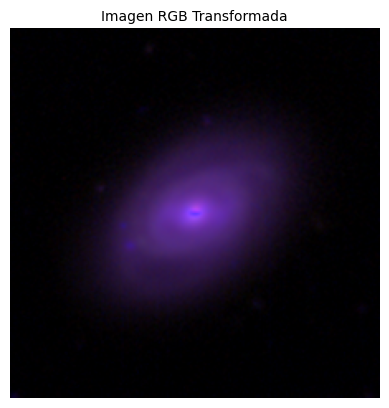

R channel range: 0.0 to 0.68367183
G channel range: 0.0 to 0.28771934
Z channel range: 0.0 to 1.0000002


In [ ]:
baseline_pipeline = transforms.Compose([
    LuptonRgbTransform(stretch=0.5, Q=10),
    EnsureCHWTransform(),
    transforms.ConvertImageDtype(torch.float32),
    transforms.Resize((224, 224)),
])

new_pipeline = transforms.Compose([
    SkySubstractTransform(),
    ToTensorIfNumpy(),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.5, 1.5)),
    MultiScaleUnsharpMaskTransform(
        sigmas=(2.5, 6.0),
        amounts=(0.6, 1.3),
        thresholds=(0.010, 0.004),
        clip_percentiles=(0.1, 99.9),
        z_amount_boost=0.0,  # keep 0 at first; your current +2.0 is quite strong
    ),
    LuptonRgbTransform(stretch=0.8, Q=10),
    EnsureCHWTransform(),

    transforms.ConvertImageDtype(torch.float32),
    transforms.Resize((224, 224)),
])

# new_pipeline = transforms.Compose([
#     SkySubstractTransform(),
#     LuptonRgbTransform(stretch=0.5, Q=10),
#     EnsureCHWTransform(),
#     transforms.ConvertImageDtype(torch.float32),
#     transforms.Resize((224, 224)),
# ])


baseline_version1 = transforms.Compose([
    SkySubstractTransform(),
    transforms.Lambda(lambda x: torch.from_numpy(x) if isinstance(x, np.ndarray) else x),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.5, 1.5)),
    LuptonRgbTransform(stretch=0.5, Q=6),
    EnsureCHWTransform(),
    transforms.ConvertImageDtype(torch.float32),
    transforms.Resize((224, 224)),
])

pipeline1 = transforms.Compose([
    MultiScaleUnsharpMaskTransform(
        sigmas=(2.5, 6.0),
        amounts=(0.6, 1.3),
        thresholds=(0.010, 0.004),
        clip_percentiles=(0.1, 99.9),
        z_amount_boost=0.0,  # keep 0 at first; your current +2.0 is quite strong
    ),
    LuptonRgbTransform(stretch=0.5, Q=6),
    EnsureCHWTransform(),

    transforms.ConvertImageDtype(torch.float32),
    transforms.Resize((224, 224)),
])

pipeline2 = transforms.Compose([
    MultiScaleUnsharpMaskTransform(
        sigmas=(2.5, 6.0),
        amounts=(0.6, 1.3),
        thresholds=(0.010, 0.004),
        clip_percentiles=(0.1, 99.9),
        z_amount_boost=0.0,  # keep 0 at first; your current +2.0 is quite strong
    ),
    LuptonRgbTransform(stretch=0.8, Q=6),
    EnsureCHWTransform(),

    transforms.ConvertImageDtype(torch.float32),
    transforms.Resize((224, 224)),
])

# (Optional) sky subtract (SkySubstractTransform)
# (Optional) mild Gaussian blur per band (denoise)
# multi-scale unsharp (MultiScaleUnsharpMaskTransform)
# Lupton RGB (LuptonRgbTransform) for visualization
pipeline3 = transforms.Compose([
    SkySubstractTransform(),
    transforms.Lambda(lambda x: torch.from_numpy(x) if isinstance(x, np.ndarray) else x),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.5, 1.5)),
    MultiScaleUnsharpMaskTransform(
        sigmas=(2.5, 6.0),
        amounts=(0.6, 1.3),
        thresholds=(0.010, 0.004),
        clip_percentiles=(0.1, 99.9),
        z_amount_boost=0.0,  # keep 0 at first; your current +2.0 is quite strong
    ),
    LuptonRgbTransform(stretch=0.8, Q=10),
    EnsureCHWTransform(),

    transforms.ConvertImageDtype(torch.float32),
    transforms.Resize((224, 224)),
])

#raw
ex = Visualization.get_raw_fits(df_dataset, example_id)
# #Visualization.plot_rgb_from_tensor(ex)
# Visualization.plot_raw_fits(ex)
Visualization.plot_rgb_from_tensor(ex)
Visualization.print_tensor_channel_ranges(ex)


ex1 = pipeline1(ex)
# Visualization.plot_3d_tensor(ex1)
#Visualization.plot_rgb_from_tensor(ex1)

ex2 = pipeline2(ex)
# Visualization.plot_3d_tensor(ex2)
Visualization.plot_rgb_from_tensor(ex2)
Visualization.print_tensor_channel_ranges(ex2)

ex3 = pipeline3(ex)
Visualization.plot_rgb_from_tensor(ex3)
Visualization.print_tensor_channel_ranges(ex3)

ex4 = baseline_pipeline(ex)
Visualization.plot_rgb_from_tensor(ex4)
Visualization.print_tensor_channel_ranges(ex4)

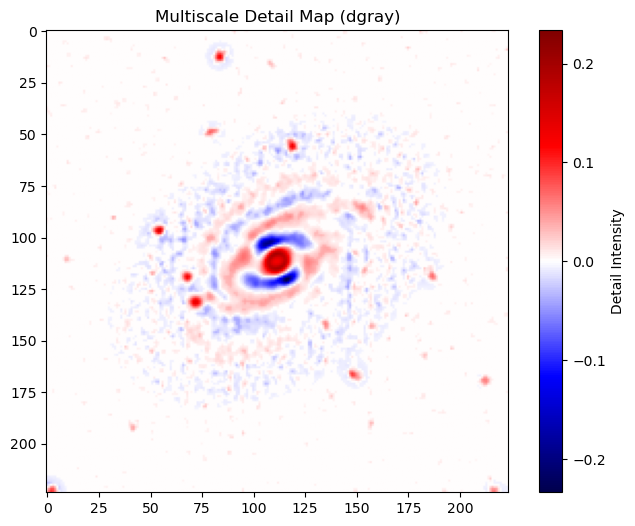

In [ ]:
def multiscale_detail_map(band2d, sigmas, amounts, thresholds):
    base = band2d.astype(np.float32, copy=False)
    detail_sum = np.zeros_like(base, dtype=np.float32)
    for sigma, amount, thr in zip(sigmas, amounts, thresholds):
        _, sharp = Transformations.unsharp_mask(base, sigma=sigma, amount=amount, threshold=thr)
        detail_sum += (sharp - base)  # detail at this scale
    return detail_sum  # can be +/- values

def rgb_like_gray(image_chw, w=(0.3, 0.59, 0.11)):
    r, g, z = image_chw[0], image_chw[1], image_chw[2]
    return (w[0]*r + w[1]*g + w[2]*z).astype(np.float32, copy=False)

gray = rgb_like_gray(ex3.numpy(), w=(0.33, 0.33, 0.34))  # or tune weights
dgray = multiscale_detail_map(
    gray, 
    sigmas=(2.5, 4.0),      # tuple of sigma values
    amounts=(0.6, 1.3),     # tuple of amount values
    thresholds=(0.010, 0.004)  # tuple of threshold values
)

#plot dgray as a 3d plot with a diverging colormap centered at 0, and limits set to the max absolute value of dgray (detail intensity as z-axis)
fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.imshow(dgray, cmap='seismic', vmin=-np.max(np.abs(dgray)), vmax=np.max(np.abs(dgray)))
ax.set_title('Multiscale Detail Map (dgray)')
fig.colorbar(cax, ax=ax, label='Detail Intensity')
plt.show()


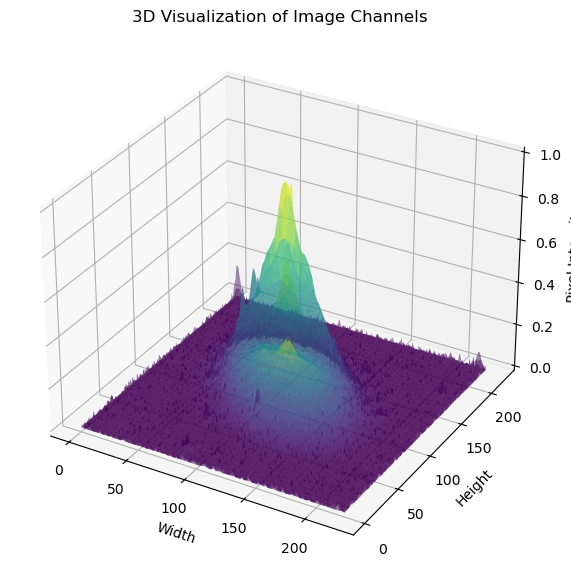

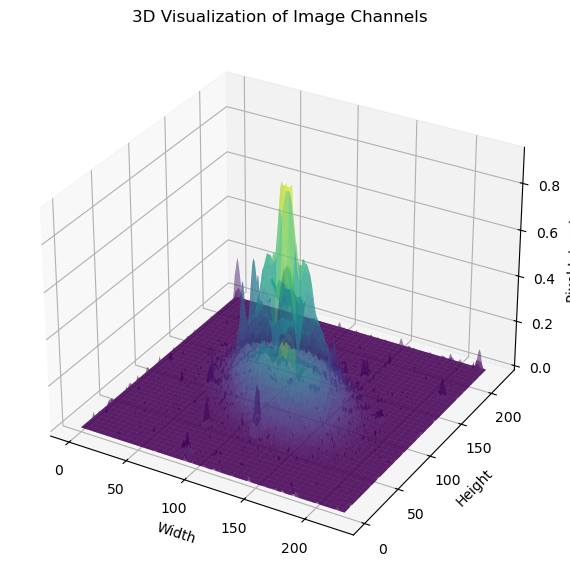

In [ ]:

#Interactive 3D visualization of the example galaxy using plotly
# %matplotlib widget

Visualization.plot_3d_tensor(baseline_pipeline(ex))
Visualization.plot_3d_tensor(new_pipeline(ex))
# Visualization.plot_3d_tensor(pipeline3(ex))
# Visualization.plot_3d_tensor(ex2)
# Visualization.plot_3d_tensor(ex3)
# Visualization.plot_3d_tensor(ex4)


## 3. Model & Data Catalog

In [ ]:
from datasets import ZoobotFitsDataModule
datamodule = ZoobotFitsDataModule(
    csv_path=os.path.join(DATA_PATH, "dataset_all_with_files_patched.csv"),
    img_dir=IMAGE_PATH,
    batch_size=64,
    num_workers=4,
    transform_pipeline=new_pipeline,
    use_augmentation=True
)

In [ ]:
#Print dataset sizes (train, val, test)
datamodule.setup()
print(f"Train dataset size: {len(datamodule.train_dataloader().dataset)}")
print(f"Validation dataset size: {len(datamodule.val_dataloader().dataset)}")
print(f"Test dataset size: {len(datamodule.test_dataloader().dataset)}")


Training class distribution (ring_class → count): {0: 5061, 1: 1013, 2: 266, 3: 336}
Train dataset size: 6676
Validation dataset size: 835
Test dataset size: 835


In [ ]:

from zoobot.pytorch.training.finetune import FinetuneableZoobotClassifier
from ring_detection_model import RingDetectionZoobot
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint

temp_model = FinetuneableZoobotClassifier(
    name='hf_hub:mwalmsley/zoobot-encoder-convnext_nano',
    num_classes=2,  # Binary multilabel
    label_col='ring_class'
)

encoder = temp_model.encoder

pos_weight = datamodule.get_pos_weight()  # Adjust based on class imbalance if needed

model_multilabel = RingDetectionZoobot(encoder=encoder, encoder_dim=640, hidden_dim=256, dropout_rate=0.4, use_head_batchnorm=True, use_focal_loss=True, pos_weight=pos_weight)

✓ Encoder frozen


## 4. Training

In [32]:
#flush cuda gc and cache before training
torch.cuda.empty_cache()

In [33]:
checkpoint_callback_stage1 = ModelCheckpoint(
    monitor='finetuning/val_loss',
    mode='min',
    save_top_k=1,
    filename='stage1-best-{epoch}',
)

trainer_stage1 = Trainer(
    max_epochs=10,
    accelerator='auto',
    devices='auto',
    enable_progress_bar=True,
    enable_model_summary=True,
    precision='16-mixed',
    callbacks=[
        checkpoint_callback_stage1,
        EarlyStopping(monitor='finetuning/val_loss', mode='min', patience=5),
    ]
)

trainer_stage1.fit(model_multilabel, datamodule=datamodule)

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training class distribution (ring_class → count): {0: 5061, 1: 1013, 2: 266, 3: 336}


c:\Users\Francisco-PC\miniconda3\envs\cnn_training\Lib\site-packages\lightning\pytorch\utilities\model_summary\model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                  ┃ Type                ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder               │ ConvNeXt            │ 15.0 M │ train │     0 │
│ 1 │ head                  │ Sequential          │  165 K │ train │     0 │
│ 2 │ train_accuracy        │ MultilabelAccuracy  │      0 │ train │     0 │
│ 3 │ val_accuracy          │ MultilabelAccuracy  │      0 │ train │     0 │
│ 4 │ train_f1_macro        │ MultilabelF1Score   │      0 │ train │     0 │
│ 5 │ val_f1_macro          │ MultilabelF1Score   │      0 │ train │     0 │
│ 6 │ train_precision_macro │ MultilabelPrecision │      0 │ train │     0 │
│ 7 │ val_precision_macro   │ MultilabelPrecision │      0 │ train │     0 │
│ 8 │ train_recall_macro    │ MultilabelRecall    │      0 │ train │     0 │
│ 9 │ val_recall_macro      │ MultilabelRecall    │      0 │ train │     0 │
└───┴───────────────────────┴─────────────────────┴────────┴───────┴───────┘

Trainable params: 165 K                                                                                            
Non-trainable params: 15.0 M                                                                                       
Total params: 15.1 M                                                                                               
Total estimated model params size (MB): 60                                                                         
Modules in train mode: 216                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

c:\Users\Francisco-PC\miniconda3\envs\cnn_training\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

c:\Users\Francisco-PC\miniconda3\envs\cnn_training\Lib\site-packages\torch\utils\data\dataloader.py:433: 
UserWarning: Got pickle error when attempting to start a worker Process. This might be because the worker Process 
arguments are not picklable. Python 3.14+ changed the multiprocessing start method in non-Mac POSIX platforms to 
'forkserver', which requires the worker Process arguments to be picklable. You can also try 
multiprocessing.set_start_method('fork').
  return _MultiProcessingDataLoaderIter(self)

PicklingError: Can't pickle <function <lambda> at 0x0000026412C26400>: it's not found as __main__.<lambda>

In [ ]:
#use this if stage1 saves a checkpoint and you want to load it directly without running stage 1 again.
#best_checkpoint = os.path.join(HOME_PATH, "lightning_logs", "version_18", "checkpoints", "stage2-best-epoch=2.ckpt")

# Stage 2: Unfreeze encoder and fine-tune with lower encoder LR
#if not os.path.exists(best_stage1_path):
best_stage1_path = checkpoint_callback_stage1.best_model_path
#best_stage1_path = best_checkpoint
model_stage2 = RingDetectionZoobot.load_from_checkpoint(
    checkpoint_path=best_stage1_path,
    encoder=encoder,
    encoder_dim=640,
    hidden_dim=256,
    dropout_rate=0.4,
    use_head_batchnorm=True,
    use_focal_loss=True,
    pos_weight=pos_weight,
    encoder_lr=5e-6,  # 20 times smaller than stage 1 LR for head
    weight_decay=1e-2  # Add weight decay for regularization in stage
)
model_stage2.unfreeze_encoder()
model_stage2.encoder_lr = 5e-6  # 20 times smaller than stage 1 LR for head
model_stage2.weight_decay = 1e-2  # Add weight decay for regularization in stage 2

checkpoint_callback_stage2 = ModelCheckpoint(
    monitor='finetuning/val_loss',
    mode='min',
    save_top_k=1,
    filename='stage2-best-{epoch}',
)

trainer_stage2 = Trainer(
    max_epochs=20,
    accelerator='auto',
    devices='auto',
    precision='16-mixed',
    enable_progress_bar=True,
    callbacks=[
        checkpoint_callback_stage2,
        EarlyStopping(monitor='finetuning/val_loss', mode='min', patience=5),
    ]
)
trainer_stage2.fit(model_stage2, datamodule=datamodule)

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


✓ Encoder frozen
✓ Encoder unfrozen
Training class distribution (ring_class → count): {0: 5061, 1: 1013, 2: 266, 3: 336}


c:\Users\Francisco-PC\miniconda3\envs\cnn_training\Lib\site-packages\lightning\pytorch\utilities\model_summary\model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                  ┃ Type                ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder               │ ConvNeXt            │ 15.0 M │ train │     0 │
│ 1 │ head                  │ Sequential          │  165 K │ train │     0 │
│ 2 │ train_accuracy        │ MultilabelAccuracy  │      0 │ train │     0 │
│ 3 │ val_accuracy          │ MultilabelAccuracy  │      0 │ train │     0 │
│ 4 │ train_f1_macro        │ MultilabelF1Score   │      0 │ train │     0 │
│ 5 │ val_f1_macro          │ MultilabelF1Score   │      0 │ train │     0 │
│ 6 │ train_precision_macro │ MultilabelPrecision │      0 │ train │     0 │
│ 7 │ val_precision_macro   │ MultilabelPrecision │      0 │ train │     0 │
│ 8 │ train_recall_macro    │ MultilabelRecall    │      0 │ train │     0 │
│ 9 │ val_recall_macro      │ MultilabelRecall    │      0 │ train │     0 │
└───┴───────────────────────┴─────────────────────┴────────┴───────┴───────┘

Trainable params: 15.1 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 15.1 M                                                                                               
Total estimated model params size (MB): 60                                                                         
Modules in train mode: 216                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

c:\Users\Francisco-PC\miniconda3\envs\cnn_training\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

## 5. Metrics

In [ ]:
# Use best Stage 2 checkpoint for evaluation (or Stage 1 if Stage 2 was skipped)
#retrieve best checkpoint path from C:\Users\Francisco-PC\Documents\Tec de Monterrey\Proyecto Integrador\Experimentos\Avance 5\lightning_logs\version_20\checkpoints\stage2-best-epoch=13.ckpt
#best_checkpoint = os.path.join(HOME_PATH, "lightning_logs", "version_17", "checkpoints", "stage2-best-epoch=5.ckpt")

#if not os.path.exists(best_checkpoint):
try:
    best_checkpoint = checkpoint_callback_stage2.best_model_path
except NameError:
    best_checkpoint = checkpoint_callback_stage2.best_model_path
finetuned_model = RingDetectionZoobot.load_from_checkpoint(
    checkpoint_path=best_checkpoint,
    encoder=encoder,
    encoder_dim=640,
    hidden_dim=256,
    dropout_rate=0.4,
    pos_weight=pos_weight,
)

✓ Encoder frozen


In [ ]:
# Per-label threshold tuning on validation set
from ring_detection_model import tune_thresholds_on_val

best_t_inner, best_t_outer = tune_thresholds_on_val(
    finetuned_model,
    datamodule.val_dataloader(),
    finetuned_model.device,
    threshold_range=(0.25, 0.95),
    step=0.02,
    metric="f1", 
)

finetuned_model.t_inner = best_t_inner
finetuned_model.t_outer = best_t_outer

print(f"Best thresholds: inner={best_t_inner}, outer={best_t_outer}")

Best thresholds: inner=0.65, outer=0.75


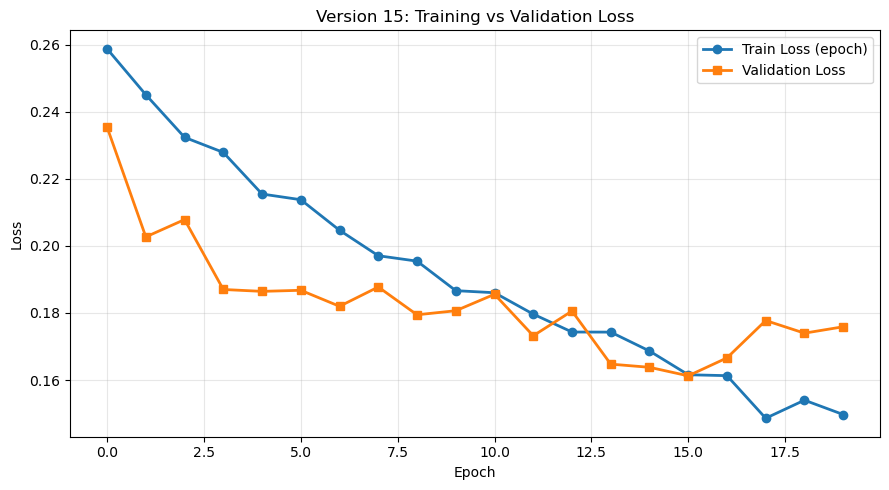

,epoch,finetuning/train_loss_epoch,finetuning/val_loss
15,15,0.161569,0.161245
16,16,0.161295,0.166600
17,17,0.148585,0.177751
18,18,0.153977,0.173981
19,19,0.149695,0.175888


In [ ]:
# Plot training and validation loss (version_15)
metrics_path = os.path.join(HOME_PATH, "lightning_logs", "version_15", "metrics.csv")
metrics_df = pd.read_csv(metrics_path)

loss_df = (
    metrics_df[["epoch", "finetuning/train_loss_epoch", "finetuning/val_loss"]]
    .groupby("epoch", as_index=False)
    .last()
    .dropna(subset=["finetuning/train_loss_epoch", "finetuning/val_loss"], how="all")
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    loss_df["epoch"],
    loss_df["finetuning/train_loss_epoch"],
    marker="o",
    linewidth=2,
    label="Train Loss (epoch)",
)
ax.plot(
    loss_df["epoch"],
    loss_df["finetuning/val_loss"],
    marker="s",
    linewidth=2,
    label="Validation Loss",
)

ax.set_title("Version 15: Training vs Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

loss_df.tail()

Predictions shape: (835, 2)
Labels shape: (835, 2)


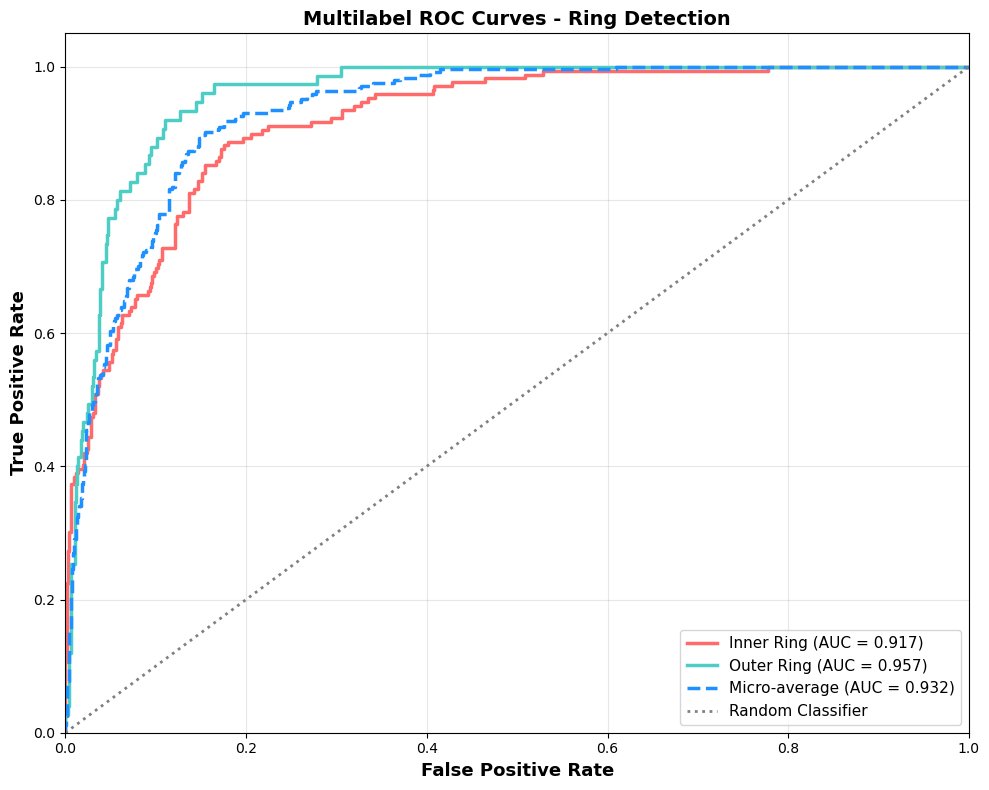


ROC AUC Scores
Inner Ring          : 0.9169
Outer Ring          : 0.9568
Micro-average       : 0.9324


In [ ]:
#Compute Confusion Matrix
import torch
import numpy as np
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Get test predictions
finetuned_model.eval()
test_loader = datamodule.test_dataloader()

all_probs = []
all_labels = []
all_inputs = []  # To store input tensors for visualization

with torch.no_grad():
    for batch in test_loader:
        x, y = finetuned_model.batch_to_supervised_tuple(batch)
        x = x.to(finetuned_model.device)
        y = y.to(finetuned_model.device)
        
        # Get probabilities (with test-time augmentation for robustness)
        probs = finetuned_model.predict_proba_tta(x, n_rotations=4, flip=True)
        
        all_probs.append(probs.cpu().numpy())
        all_labels.append(y.cpu().numpy())
        all_inputs.append(x.cpu())  # <- keep sample tensors for click visualization


# Concatenate all batches
probs_all = np.concatenate(all_probs, axis=0)  # Shape: (n_samples, 2)
labels_all = np.concatenate(all_labels, axis=0)  # Shape: (n_samples, 2)
inputs_all = torch.cat(all_inputs, dim=0)  # shape: (N, C, H, W)

print(f"Predictions shape: {probs_all.shape}")
print(f"Labels shape: {labels_all.shape}")

# Compute ROC curves for each label
fig, ax = plt.subplots(figsize=(10, 8))

label_names = ['Inner Ring', 'Outer Ring']
colors = ['#FF6B6B', '#4ECDC4']
fprs = []
tprs = []
aucs = []

# Plot ROC curves for each label (take best_t_inner and best_t_outer as thresholds)

for label_idx, label_name in enumerate(label_names):
    fpr, tpr, _ = roc_curve(labels_all[:, label_idx], probs_all[:, label_idx])
    roc_auc = auc(fpr, tpr)
    
    fprs.append(fpr)
    tprs.append(tpr)
    aucs.append(roc_auc)
    
    ax.plot(fpr, tpr, color=colors[label_idx], lw=2.5, 
            label=f'{label_name} (AUC = {roc_auc:.3f})')

# Plot combined micro-average ROC curve
fpr_micro, tpr_micro, _ = roc_curve(labels_all.ravel(), probs_all.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)

ax.plot(fpr_micro, tpr_micro, color='#1E90FF', lw=2.5, linestyle='--',
        label=f'Micro-average (AUC = {roc_auc_micro:.3f})')

# Plot diagonal (random classifier)
ax.plot([0, 1], [0, 1], color='gray', lw=2, linestyle=':', label='Random Classifier')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=13, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=13, fontweight='bold')
ax.set_title('Multilabel ROC Curves - Ring Detection', fontsize=14, fontweight='bold')
ax.legend(loc="lower right", fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print AUC scores
print("\n" + "="*50)
print("ROC AUC Scores")
print("="*50)
for i, label_name in enumerate(label_names):
    print(f"{label_name:20s}: {aucs[i]:.4f}")
print(f"{'Micro-average':20s}: {roc_auc_micro:.4f}")
print("="*50)

Binary predictions shape: (835, 2)
Binary labels shape: (835, 2)


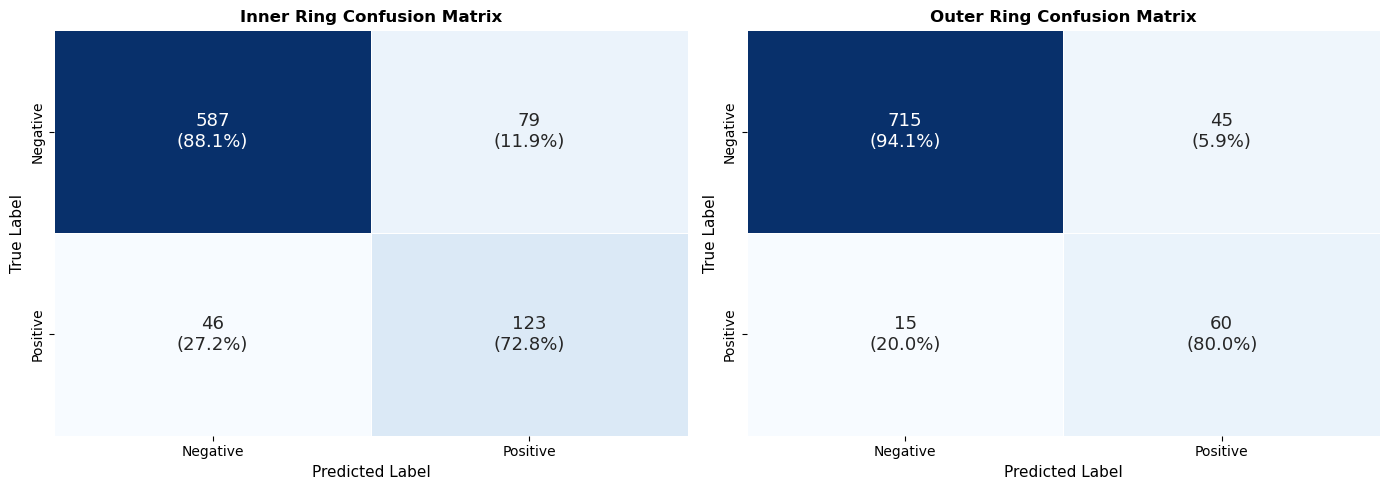

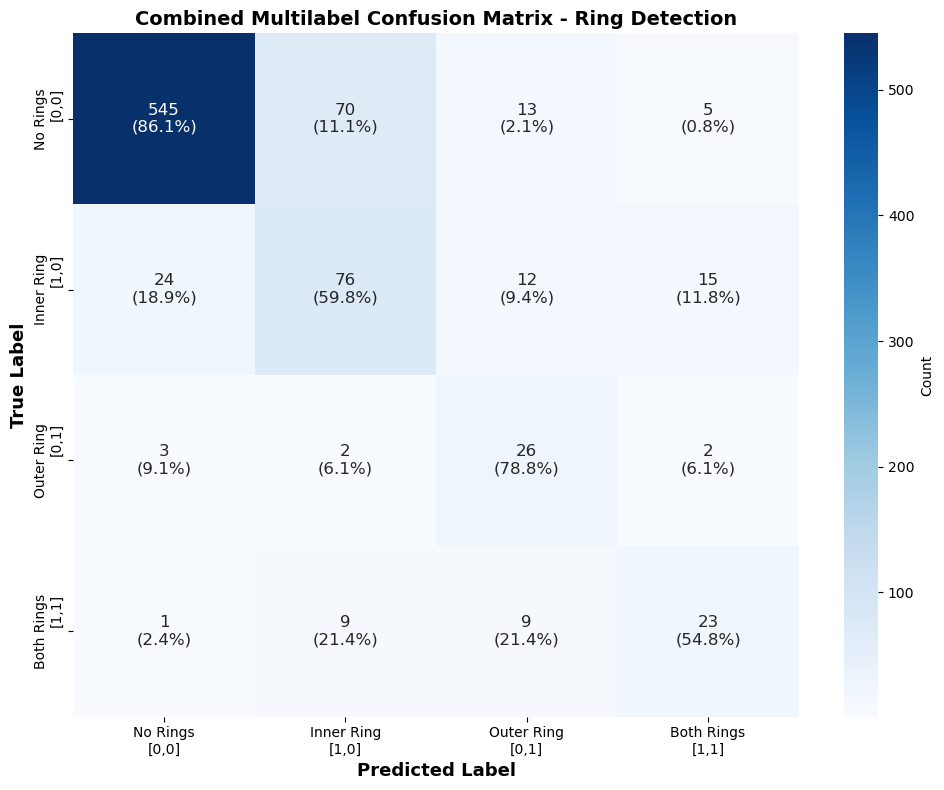


Per-Label Confusion Matrix Statistics

Inner Ring:
  True Negatives:  587
  False Positives: 79
  False Negatives: 46
  True Positives:  123
  Accuracy:  0.8503
  Precision: 0.6089
  Recall:    0.7278
  F1-Score:  0.6631

Outer Ring:
  True Negatives:  715
  False Positives: 45
  False Negatives: 15
  True Positives:  60
  Accuracy:  0.9281
  Precision: 0.5714
  Recall:    0.8000
  F1-Score:  0.6667


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Generate binary predictions (take best_t_inner and best_t_outer as thresholds)
preds_binary = np.zeros_like(probs_all, dtype=int)
preds_binary[:, 0] = (probs_all[:, 0] > best_t_inner).astype(int)  # Inner ring prediction
preds_binary[:, 1] = (probs_all[:, 1] > best_t_outer).astype(int)  # Outer ring prediction

labels_binary = labels_all.astype(int)  # Shape: (n_samples, 2)

print(f"Binary predictions shape: {preds_binary.shape}")
print(f"Binary labels shape: {labels_binary.shape}")

# Create confusion matrices for each label
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

label_names = ['Inner Ring', 'Outer Ring']

for label_idx, label_name in enumerate(label_names):
    cm = confusion_matrix(labels_binary[:, label_idx], preds_binary[:, label_idx])

    # Row-wise percentages (% of true class)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    annot = np.array([
        [f"{count}\n({pct:.1f}%)" for count, pct in zip(row_c, row_p)]
        for row_c, row_p in zip(cm, cm_pct)
    ])

    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', ax=axes[label_idx],
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'],
                cbar=False, linewidths=0.5, annot_kws={'size': 13})

    axes[label_idx].set_xlabel('Predicted Label', fontsize=11)
    axes[label_idx].set_ylabel('True Label', fontsize=11)
    axes[label_idx].set_title(f'{label_name} Confusion Matrix', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Create combined confusion matrix (4 classes: [0,0], [1,0], [0,1], [1,1])
# Map each sample to its label combination
label_combinations = np.array([f"{labels_binary[i, 0]}{labels_binary[i, 1]}" for i in range(len(labels_binary))]).astype(int)
pred_combinations = np.array([f"{preds_binary[i, 0]}{preds_binary[i, 1]}" for i in range(len(preds_binary))]).astype(int)

# Create mapping: 00 -> 0, 10 -> 1, 01 -> 2, 11 -> 3
combination_map = {0: 0, 10: 1, 1: 2, 11: 3}
label_combo_mapped = np.array([combination_map[lc] for lc in label_combinations])
pred_combo_mapped = np.array([combination_map[pc] for pc in pred_combinations])

cm_combined = confusion_matrix(label_combo_mapped, pred_combo_mapped, labels=[0, 1, 2, 3])

# Row-wise percentages for combined matrix
cm_combined_pct = cm_combined.astype(float) / cm_combined.sum(axis=1, keepdims=True) * 100
annot_combined = np.array([
    [f"{count}\n({pct:.1f}%)" for count, pct in zip(row_c, row_p)]
    for row_c, row_p in zip(cm_combined, cm_combined_pct)
])

# Plot combined confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
combo_labels = ['No Rings\n[0,0]', 'Inner Ring\n[1,0]', 'Outer Ring\n[0,1]', 'Both Rings\n[1,1]']

sns.heatmap(cm_combined, annot=annot_combined, fmt='', cmap='Blues', ax=ax,
            xticklabels=combo_labels, yticklabels=combo_labels,
            cbar_kws={'label': 'Count'}, annot_kws={'size': 12})

ax.set_xlabel('Predicted Label', fontsize=13, fontweight='bold')
ax.set_ylabel('True Label', fontsize=13, fontweight='bold')
ax.set_title('Combined Multilabel Confusion Matrix - Ring Detection', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Print detailed statistics
print("\n" + "="*60)
print("Per-Label Confusion Matrix Statistics")
print("="*60)

for label_idx, label_name in enumerate(label_names):
    cm = confusion_matrix(labels_binary[:, label_idx], preds_binary[:, label_idx])
    tn, fp, fn, tp = cm.ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    print(f"\n{label_name}:")
    print(f"  True Negatives:  {tn}")
    print(f"  False Positives: {fp}")
    print(f"  False Negatives: {fn}")
    print(f"  True Positives:  {tp}")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

print("="*60)
